In [2]:
import json
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOTS = {
    "AVA": "/home/erik/NAS/methods/diffusion_gen/data/diffusion/ava",
    "Waymo": "/home/erik/NAS/methods/diffusion_gen/data/diffusion/waymo",
    "nuScenes": "/home/erik/NAS/methods/diffusion_gen/data/diffusion/nuscenes",
}

def collect_lengths(data_root):
    """Collect ego and motion lengths from all JSON files in train/ and val/."""
    ego_lengths = []
    motion_lengths = []
    for split in ["train", "val"]:
        split_dir = os.path.join(data_root, split)
        if not os.path.isdir(split_dir):
            continue
        for fpath in sorted(glob(os.path.join(split_dir, "*.json"))):
            with open(fpath) as f:
                data = json.load(f)
            ego_lengths.append(len(data["ego_in_ped_frame"]))
            motion_lengths.append(len(data["vectors_263"]))
    return np.array(ego_lengths), np.array(motion_lengths)

# Collect per-dataset
stats = {}
for name, root in DATA_ROOTS.items():
    ego, motion = collect_lengths(root)
    stats[name] = {"ego": ego, "motion": motion}
    print(f"{name}: {len(ego)} scenes")

print(f"\nTotal: {sum(len(s['ego']) for s in stats.values())} scenes")

AVA: 34 scenes
Waymo: 9624 scenes
nuScenes: 4514 scenes

Total: 14172 scenes


In [3]:
# --- Average lengths table ---
print(f"{'Dataset':<12} {'N':>6} {'Avg Ego':>10} {'Avg Motion':>12} {'Min Ego':>9} {'Max Ego':>9} {'Min Mot':>9} {'Max Mot':>9}")
print("-" * 82)
for name, s in stats.items():
    print(f"{name:<12} {len(s['ego']):>6} {s['ego'].mean():>10.1f} {s['motion'].mean():>12.1f} "
          f"{s['ego'].min():>9} {s['ego'].max():>9} {s['motion'].min():>9} {s['motion'].max():>9}")

# Combined
all_ego = np.concatenate([s["ego"] for s in stats.values()])
all_motion = np.concatenate([s["motion"] for s in stats.values()])
print("-" * 82)
print(f"{'Combined':<12} {len(all_ego):>6} {all_ego.mean():>10.1f} {all_motion.mean():>12.1f} "
      f"{all_ego.min():>9} {all_ego.max():>9} {all_motion.min():>9} {all_motion.max():>9}")

Dataset           N    Avg Ego   Avg Motion   Min Ego   Max Ego   Min Mot   Max Mot
----------------------------------------------------------------------------------
AVA              34      209.3        208.3        22       486        21       485
Waymo          9624      190.2        189.2         8       398         7       397
nuScenes       4514      200.0        199.0        12       402        11       401
----------------------------------------------------------------------------------
Combined      14172      193.4        192.4         8       486         7       485


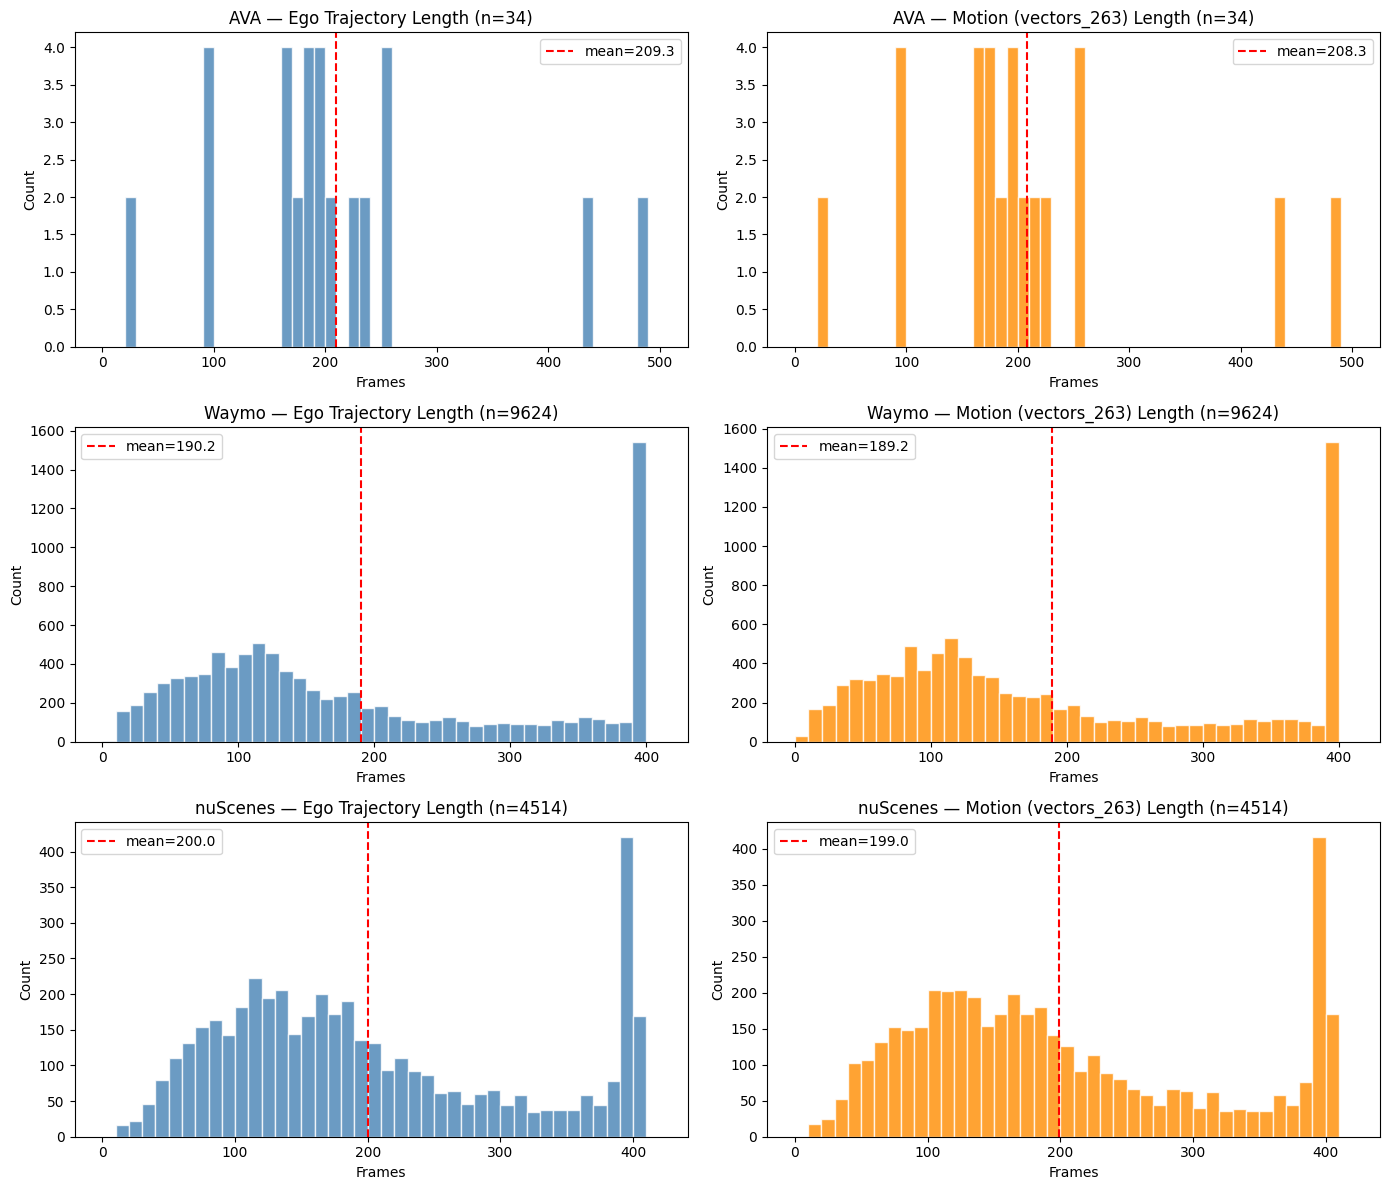

In [4]:
# --- Per-dataset histograms ---
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, (name, s) in enumerate(stats.items()):
    bins = np.arange(0, max(s["ego"].max(), s["motion"].max()) + 20, 10)

    axes[i, 0].hist(s["ego"], bins=bins, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i, 0].axvline(s["ego"].mean(), color="red", linestyle="--", label=f"mean={s['ego'].mean():.1f}")
    axes[i, 0].set_title(f"{name} — Ego Trajectory Length (n={len(s['ego'])})")
    axes[i, 0].set_xlabel("Frames")
    axes[i, 0].set_ylabel("Count")
    axes[i, 0].legend()

    axes[i, 1].hist(s["motion"], bins=bins, color="darkorange", edgecolor="white", alpha=0.8)
    axes[i, 1].axvline(s["motion"].mean(), color="red", linestyle="--", label=f"mean={s['motion'].mean():.1f}")
    axes[i, 1].set_title(f"{name} — Motion (vectors_263) Length (n={len(s['motion'])})")
    axes[i, 1].set_xlabel("Frames")
    axes[i, 1].set_ylabel("Count")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

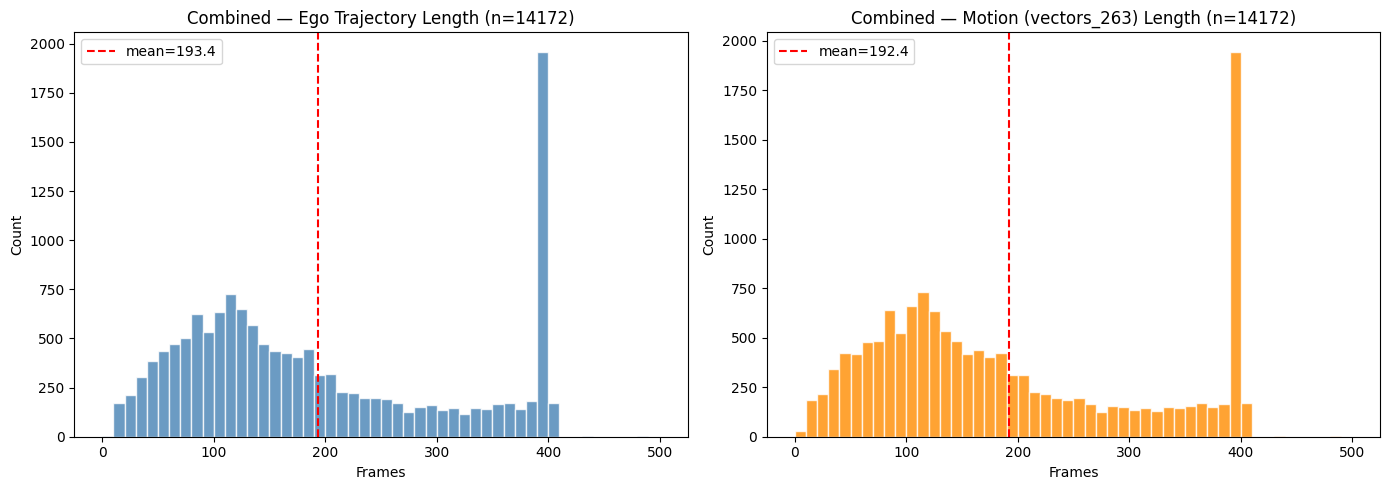

In [5]:
# --- Combined histogram (all datasets) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0, max(all_ego.max(), all_motion.max()) + 20, 10)

axes[0].hist(all_ego, bins=bins, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(all_ego.mean(), color="red", linestyle="--", label=f"mean={all_ego.mean():.1f}")
axes[0].set_title(f"Combined — Ego Trajectory Length (n={len(all_ego)})")
axes[0].set_xlabel("Frames")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(all_motion, bins=bins, color="darkorange", edgecolor="white", alpha=0.8)
axes[1].axvline(all_motion.mean(), color="red", linestyle="--", label=f"mean={all_motion.mean():.1f}")
axes[1].set_title(f"Combined — Motion (vectors_263) Length (n={len(all_motion)})")
axes[1].set_xlabel("Frames")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

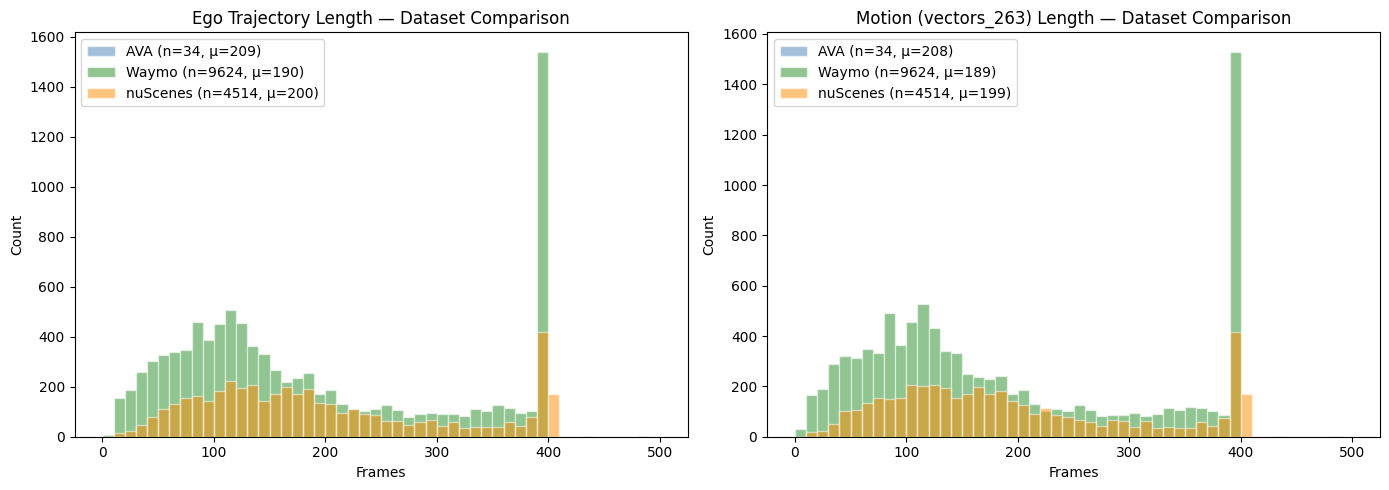

In [6]:
# --- Overlaid comparison across datasets ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"AVA": "steelblue", "Waymo": "forestgreen", "nuScenes": "darkorange"}
bins = np.arange(0, max(all_ego.max(), all_motion.max()) + 20, 10)

for name, s in stats.items():
    axes[0].hist(s["ego"], bins=bins, color=colors[name], alpha=0.5, edgecolor="white",
                 label=f"{name} (n={len(s['ego'])}, μ={s['ego'].mean():.0f})")
    axes[1].hist(s["motion"], bins=bins, color=colors[name], alpha=0.5, edgecolor="white",
                 label=f"{name} (n={len(s['motion'])}, μ={s['motion'].mean():.0f})")

axes[0].set_title("Ego Trajectory Length — Dataset Comparison")
axes[0].set_xlabel("Frames")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].set_title("Motion (vectors_263) Length — Dataset Comparison")
axes[1].set_xlabel("Frames")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## Pedestrian & Ego Traveled Distance + Interaction Metrics

Compute per-scenario metrics that help identify scenes with meaningful ego–pedestrian interactions.

**Coordinate convention:** Y is vertical (height); X and Z span the ground plane. Joint 0 in `ped_in_ped_frame` is the pelvis/root.

In [7]:
import pandas as pd

def compute_scenario_metrics(data):
    """Compute per-scenario metrics from a single JSON record.
    
    Returns a dict with:
      - ped_travel_dist:   total ground-plane (XZ) path length of the pedestrian root joint
      - ego_travel_dist:   total ground-plane (XZ) path length of the ego vehicle
      - ped_displacement:  straight-line start→end displacement of pedestrian (XZ)
      - ego_displacement:  straight-line start→end displacement of ego (XZ)
      - min_ego_ped_dist:  minimum ego–ped distance on the ground plane
      - mean_ego_ped_dist: mean ego–ped distance on the ground plane
      - ego_ped_dist_start: ego–ped distance at the first frame
      - ego_ped_dist_end:   ego–ped distance at the last frame
      - approach_ratio:     (dist_start − dist_end) / dist_start  (>0 = ego approaches ped)
      - pct_within_5m:     % of frames where ego–ped distance < 5 m
      - pct_within_10m:    % of frames where ego–ped distance < 10 m
      - ped_mean_speed:    mean per-frame speed of ped root (m/frame)
      - ped_speed_std:     std of per-frame speed of ped root
      - ego_mean_speed:    mean per-frame speed of ego (m/frame)
      - ego_speed_std:     std of per-frame speed of ego
      - heading_change_deg: total absolute heading change of ego→ped bearing vector (degrees)
      - n_frames:          number of motion frames
    """
    ego = np.array(data["ego_in_ped_frame"])        # (T+1, 3)
    ped = np.array(data["ped_in_ped_frame"])         # (T, 22, 3)
    root = ped[:, 0, :]                              # (T, 3)

    # Align lengths (ego may have 1 extra frame)
    T = min(len(ego), len(root))
    ego_aligned = ego[:T]
    root_aligned = root[:T]

    # Ground-plane projections (XZ)
    ego_xz = ego_aligned[:, [0, 2]]
    root_xz = root_aligned[:, [0, 2]]

    # --- Travel distances (cumulative path length) ---
    ped_steps = np.linalg.norm(np.diff(root_xz, axis=0), axis=1)
    ego_steps = np.linalg.norm(np.diff(ego_xz, axis=0), axis=1)
    ped_travel = ped_steps.sum()
    ego_travel = ego_steps.sum()

    # --- Displacement (straight-line start→end) ---
    ped_disp = np.linalg.norm(root_xz[-1] - root_xz[0])
    ego_disp = np.linalg.norm(ego_xz[-1] - ego_xz[0])

    # --- Ego–pedestrian distance over time ---
    ego_ped_dists = np.linalg.norm(ego_xz - root_xz, axis=1)
    min_dist = ego_ped_dists.min()
    mean_dist = ego_ped_dists.mean()
    dist_start = ego_ped_dists[0]
    dist_end = ego_ped_dists[-1]
    approach_ratio = (dist_start - dist_end) / max(dist_start, 1e-6)

    pct_5 = (ego_ped_dists < 5).mean() * 100
    pct_10 = (ego_ped_dists < 10).mean() * 100

    # --- Speeds ---
    ped_speed = ped_steps   # m / frame
    ego_speed = ego_steps

    # --- Heading change of ego→ped bearing ---
    bearing_vec = root_xz - ego_xz                    # (T, 2)
    angles = np.arctan2(bearing_vec[:, 1], bearing_vec[:, 0])
    angle_diffs = np.abs(np.diff(angles))
    # wrap to [-π, π]
    angle_diffs = np.minimum(angle_diffs, 2 * np.pi - angle_diffs)
    heading_change = np.degrees(angle_diffs.sum())

    return {
        "ped_travel_dist": ped_travel,
        "ego_travel_dist": ego_travel,
        "ped_displacement": ped_disp,
        "ego_displacement": ego_disp,
        "min_ego_ped_dist": min_dist,
        "mean_ego_ped_dist": mean_dist,
        "ego_ped_dist_start": dist_start,
        "ego_ped_dist_end": dist_end,
        "approach_ratio": approach_ratio,
        "pct_within_5m": pct_5,
        "pct_within_10m": pct_10,
        "ped_mean_speed": ped_speed.mean(),
        "ped_speed_std": ped_speed.std(),
        "ego_mean_speed": ego_speed.mean(),
        "ego_speed_std": ego_speed.std(),
        "heading_change_deg": heading_change,
        "n_frames": T,
    }


# --- Compute metrics for every scenario across all datasets ---
rows = []
for ds_name, ds_root in DATA_ROOTS.items():
    for split in ["train", "val"]:
        split_dir = os.path.join(ds_root, split)
        if not os.path.isdir(split_dir):
            continue
        for fpath in sorted(glob(os.path.join(split_dir, "*.json"))):
            with open(fpath) as f:
                data = json.load(f)
            m = compute_scenario_metrics(data)
            m["dataset"] = ds_name
            m["split"] = split
            m["scene_id"] = data["scene_id"]
            m["object_id"] = data["object_id"]
            m["file"] = os.path.basename(fpath)
            rows.append(m)

df = pd.DataFrame(rows)
print(f"Computed metrics for {len(df)} scenarios")
df.head()

Computed metrics for 14172 scenarios


,ped_travel_dist,ego_travel_dist,ped_displacement,ego_displacement,min_ego_ped_dist,mean_ego_ped_dist,ego_ped_dist_start,ego_ped_dist_end,approach_ratio,pct_within_5m,...,ped_speed_std,ego_mean_speed,ego_speed_std,heading_change_deg,n_frames,dataset,split,scene_id,object_id,file
0,8.189965,36.566672,1.603757,36.549327,2.680611,12.572612,30.613286,7.509386,0.754702,21.621622,...,0.029396,0.198732,0.109966,166.683098,185,AVA,train,0001,33,0001_33.json
1,10.491840,39.143012,3.191012,39.012408,5.616387,13.399773,33.432793,6.994414,0.790792,0.000000,...,0.021950,0.152902,0.121769,136.159779,257,AVA,train,0003,36,0003_36.json
2,16.488690,32.057461,13.933647,32.014060,8.147618,13.135397,30.632103,10.973185,0.641775,0.000000,...,0.028358,0.147053,0.131931,123.209315,219,AVA,train,0004,20,0004_20.json
3,14.216028,30.958321,11.734352,30.861434,7.622903,13.271419,32.804881,8.483779,0.741387,0.000000,...,0.027027,0.135782,0.137633,93.473598,229,AVA,train,0006,21,0006_21.json
4,9.022521,18.724979,8.290538,18.675152,8.810814,13.410141,25.962137,8.842572,0.659405,0.000000,...,0.017347,0.114177,0.105097,41.298323,165,AVA,train,0007,31,0007_31.json


### Per-dataset summary statistics

In [8]:
# --- Per-dataset summary table ---
metric_cols = [
    "ped_travel_dist", "ego_travel_dist",
    "min_ego_ped_dist", "mean_ego_ped_dist",
    "pct_within_5m", "pct_within_10m",
    "ped_mean_speed", "ego_mean_speed",
    "heading_change_deg", "n_frames",
]

summary = df.groupby("dataset")[metric_cols].agg(["mean", "std", "min", "max"])
# Flatten multi-index columns for readability
summary.columns = [f"{col}_{stat}" for col, stat in summary.columns]
summary.round(2)

,ped_travel_dist_mean,ped_travel_dist_std,ped_travel_dist_min,ped_travel_dist_max,ego_travel_dist_mean,ego_travel_dist_std,ego_travel_dist_min,ego_travel_dist_max,min_ego_ped_dist_mean,min_ego_ped_dist_std,...,ego_mean_speed_min,ego_mean_speed_max,heading_change_deg_mean,heading_change_deg_std,heading_change_deg_min,heading_change_deg_max,n_frames_mean,n_frames_std,n_frames_min,n_frames_max
dataset,,,,,,,,,,,,,,,,,,,,,
AVA,12.89,6.62,0.71,25.84,29.30,12.94,2.89,60.23,6.61,2.36,...,0.09,0.21,105.48,61.01,4.99,236.12,208.29,109.91,21,485
Waymo,8.87,9.30,0.00,93.78,24.58,16.54,0.00,95.18,12.78,6.48,...,0.00,0.99,68.50,34.92,0.02,259.54,189.21,125.36,7,397
nuScenes,9.20,8.97,0.00,46.93,33.25,20.03,0.00,119.24,9.42,4.61,...,0.00,0.74,106.76,52.21,0.08,318.35,198.98,111.63,11,401


### Pedestrian Traveled Distance (histograms per dataset + combined)

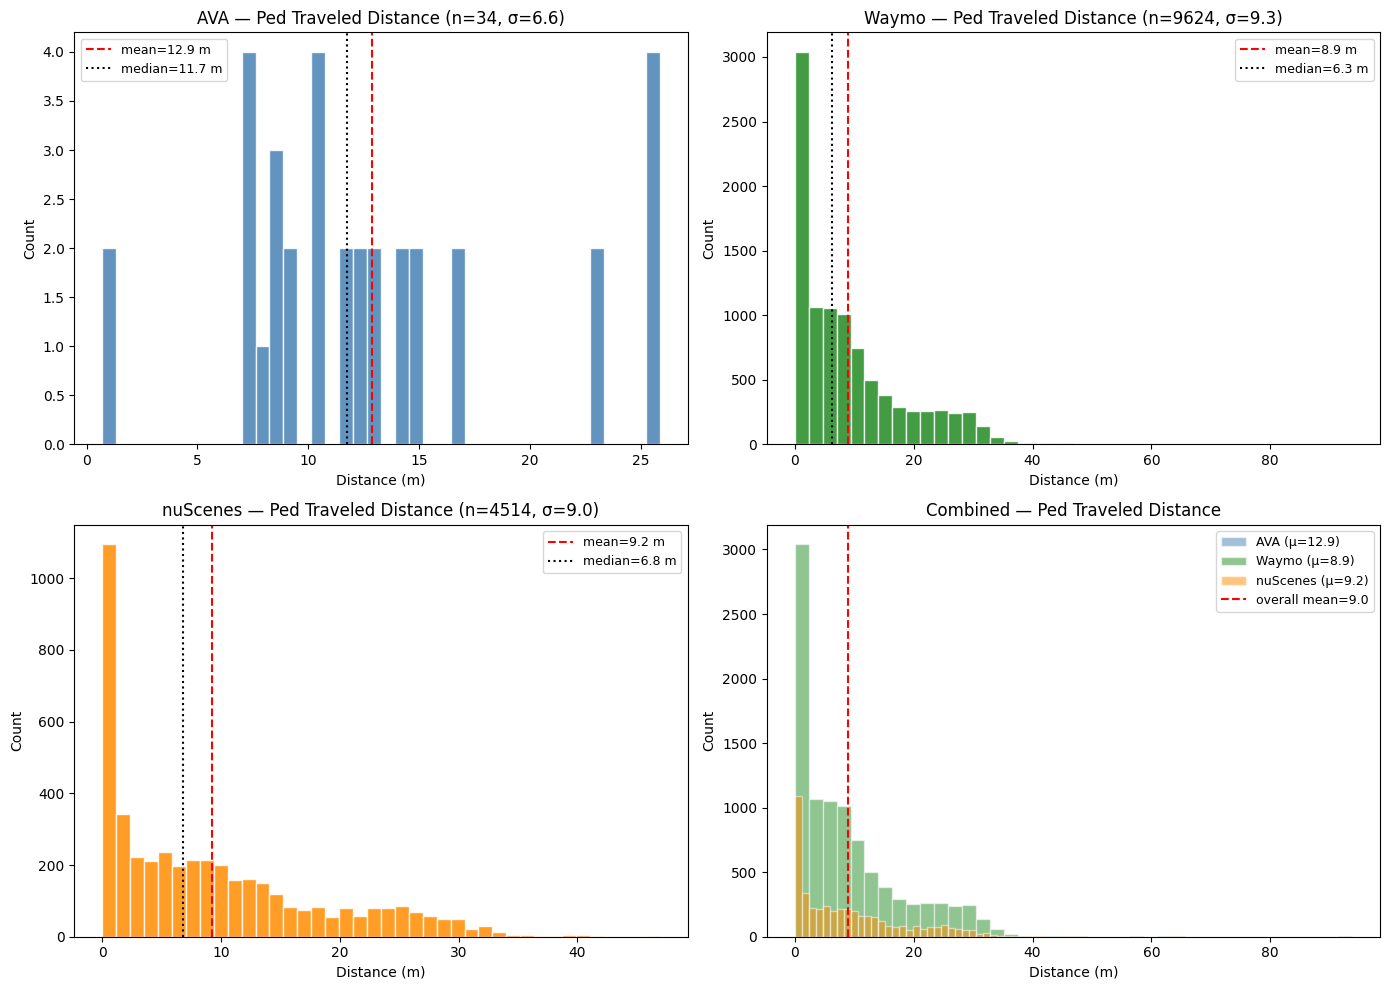


Pedestrian Traveled Distance — Overall: mean=8.99 m, std=9.19 m, median=6.47 m


In [9]:
# --- Pedestrian traveled distance histograms ---
datasets_in_order = ["AVA", "Waymo", "nuScenes"]
colors = {"AVA": "steelblue", "Waymo": "forestgreen", "nuScenes": "darkorange"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, ds in enumerate(datasets_in_order):
    ax = axes[i // 2, i % 2]
    subset = df[df.dataset == ds]["ped_travel_dist"]
    ax.hist(subset, bins=40, color=colors[ds], edgecolor="white", alpha=0.85)
    ax.axvline(subset.mean(), color="red", ls="--", lw=1.5,
               label=f"mean={subset.mean():.1f} m")
    ax.axvline(subset.median(), color="black", ls=":", lw=1.5,
               label=f"median={subset.median():.1f} m")
    ax.set_title(f"{ds} — Ped Traveled Distance (n={len(subset)}, σ={subset.std():.1f})")
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

# Combined
ax = axes[1, 1]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["ped_travel_dist"]
    ax.hist(subset, bins=40, color=colors[ds], alpha=0.5, edgecolor="white",
            label=f"{ds} (μ={subset.mean():.1f})")
ax.axvline(df["ped_travel_dist"].mean(), color="red", ls="--", lw=1.5,
           label=f"overall mean={df['ped_travel_dist'].mean():.1f}")
ax.set_title("Combined — Ped Traveled Distance")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nPedestrian Traveled Distance — Overall: "
      f"mean={df['ped_travel_dist'].mean():.2f} m, "
      f"std={df['ped_travel_dist'].std():.2f} m, "
      f"median={df['ped_travel_dist'].median():.2f} m")

### Ego Traveled Distance (histograms per dataset + combined)

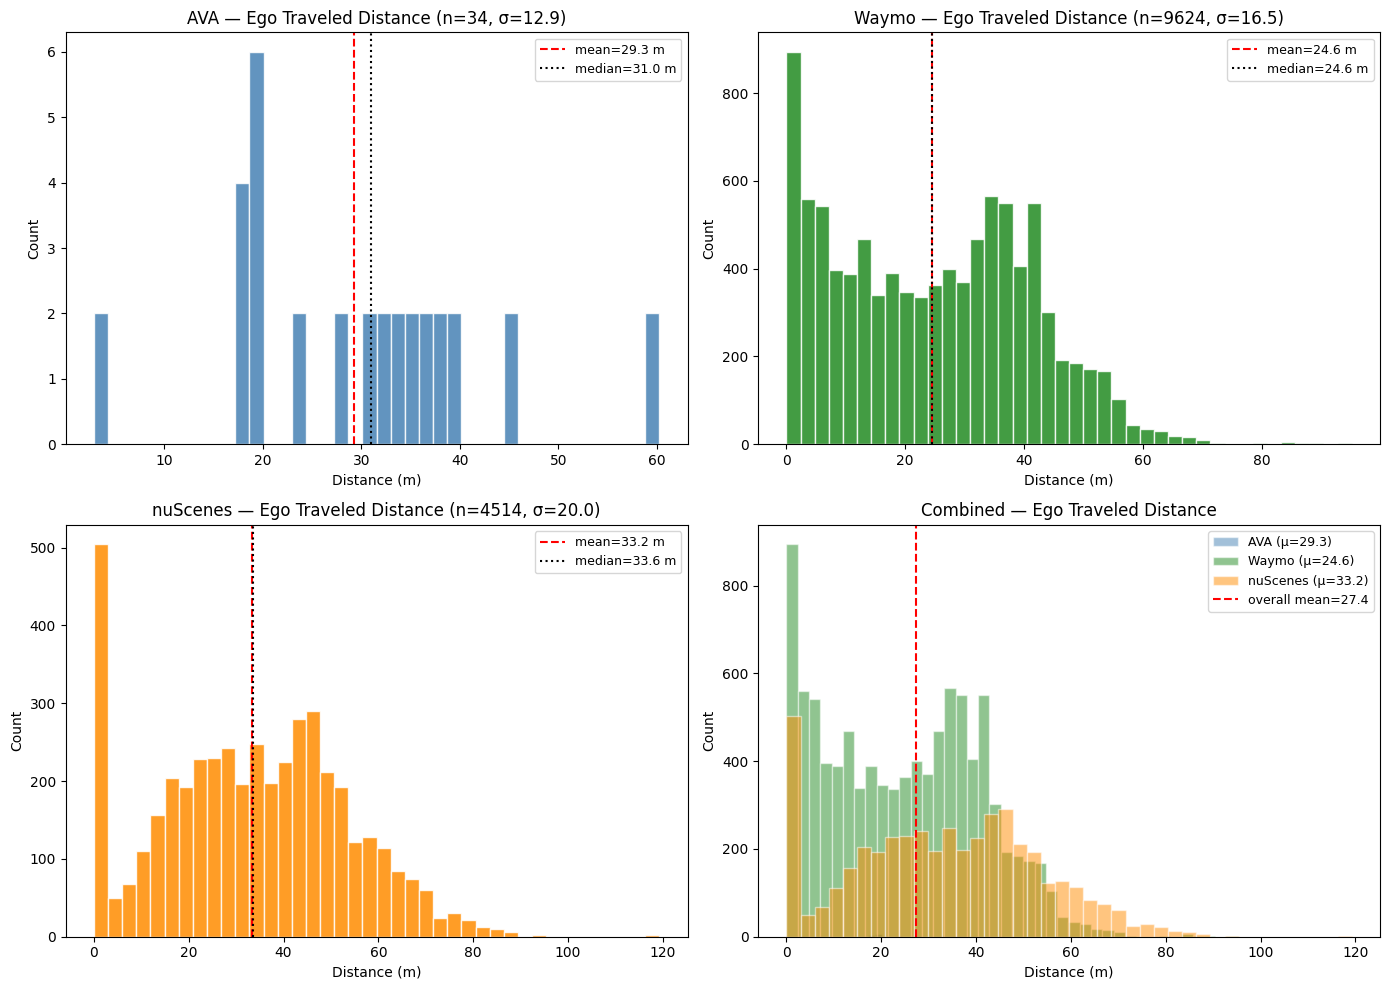


Ego Traveled Distance — Overall: mean=27.35 m, std=18.17 m, median=27.77 m


In [10]:
# --- Ego traveled distance histograms ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, ds in enumerate(datasets_in_order):
    ax = axes[i // 2, i % 2]
    subset = df[df.dataset == ds]["ego_travel_dist"]
    ax.hist(subset, bins=40, color=colors[ds], edgecolor="white", alpha=0.85)
    ax.axvline(subset.mean(), color="red", ls="--", lw=1.5,
               label=f"mean={subset.mean():.1f} m")
    ax.axvline(subset.median(), color="black", ls=":", lw=1.5,
               label=f"median={subset.median():.1f} m")
    ax.set_title(f"{ds} — Ego Traveled Distance (n={len(subset)}, σ={subset.std():.1f})")
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

ax = axes[1, 1]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["ego_travel_dist"]
    ax.hist(subset, bins=40, color=colors[ds], alpha=0.5, edgecolor="white",
            label=f"{ds} (μ={subset.mean():.1f})")
ax.axvline(df["ego_travel_dist"].mean(), color="red", ls="--", lw=1.5,
           label=f"overall mean={df['ego_travel_dist'].mean():.1f}")
ax.set_title("Combined — Ego Traveled Distance")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nEgo Traveled Distance — Overall: "
      f"mean={df['ego_travel_dist'].mean():.2f} m, "
      f"std={df['ego_travel_dist'].std():.2f} m, "
      f"median={df['ego_travel_dist'].median():.2f} m")

### Ego–Pedestrian Proximity Metrics

Key indicators for interaction quality:
- **Minimum distance**: how close the ego gets to the pedestrian (lower = stronger interaction)
- **% time within 5 m / 10 m**: duration of close proximity
- **Approach ratio**: (dist_start − dist_end) / dist_start; positive means ego ends closer to ped

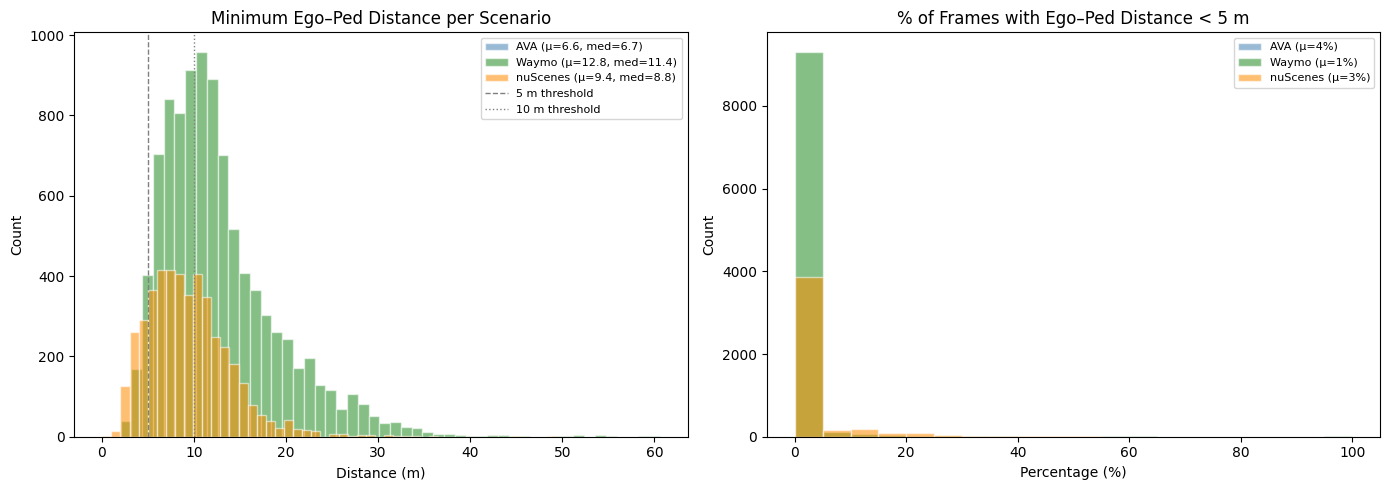

       AVA: min_dist mean=6.6 m, <5m in 4% frames, <10m in 51% frames
     Waymo: min_dist mean=12.8 m, <5m in 1% frames, <10m in 15% frames
  nuScenes: min_dist mean=9.4 m, <5m in 3% frames, <10m in 22% frames


In [11]:
# --- Minimum ego–ped distance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-dataset overlaid histogram
ax = axes[0]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["min_ego_ped_dist"]
    ax.hist(subset, bins=50, color=colors[ds], alpha=0.55, edgecolor="white",
            label=f"{ds} (μ={subset.mean():.1f}, med={subset.median():.1f})")
ax.axvline(5, color="grey", ls="--", lw=1, label="5 m threshold")
ax.axvline(10, color="grey", ls=":", lw=1, label="10 m threshold")
ax.set_title("Minimum Ego–Ped Distance per Scenario")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# % of frames within 5 m
ax = axes[1]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["pct_within_5m"]
    ax.hist(subset, bins=np.arange(0, 105, 5), color=colors[ds], alpha=0.55,
            edgecolor="white",
            label=f"{ds} (μ={subset.mean():.0f}%)")
ax.set_title("% of Frames with Ego–Ped Distance < 5 m")
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary print
for ds in datasets_in_order:
    s = df[df.dataset == ds]
    print(f"{ds:>10}: min_dist mean={s.min_ego_ped_dist.mean():.1f} m, "
          f"<5m in {s.pct_within_5m.mean():.0f}% frames, "
          f"<10m in {s.pct_within_10m.mean():.0f}% frames")

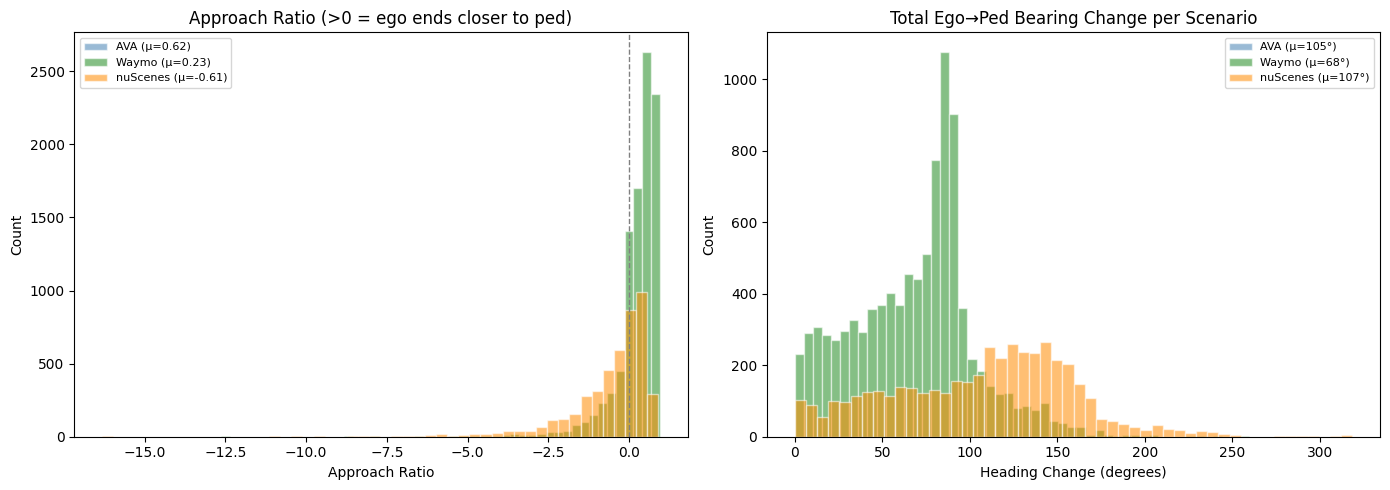

In [12]:
# --- Approach ratio & heading change ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["approach_ratio"]
    ax.hist(subset, bins=50, color=colors[ds], alpha=0.55, edgecolor="white",
            label=f"{ds} (μ={subset.mean():.2f})")
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_title("Approach Ratio (>0 = ego ends closer to ped)")
ax.set_xlabel("Approach Ratio")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

ax = axes[1]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["heading_change_deg"]
    ax.hist(subset, bins=50, color=colors[ds], alpha=0.55, edgecolor="white",
            label=f"{ds} (μ={subset.mean():.0f}°)")
ax.set_title("Total Ego→Ped Bearing Change per Scenario")
ax.set_xlabel("Heading Change (degrees)")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Pedestrian Speed and Motion Intensity

Scenarios where the pedestrian moves more (higher speed, higher speed variability) are more likely to involve reactive behaviour.

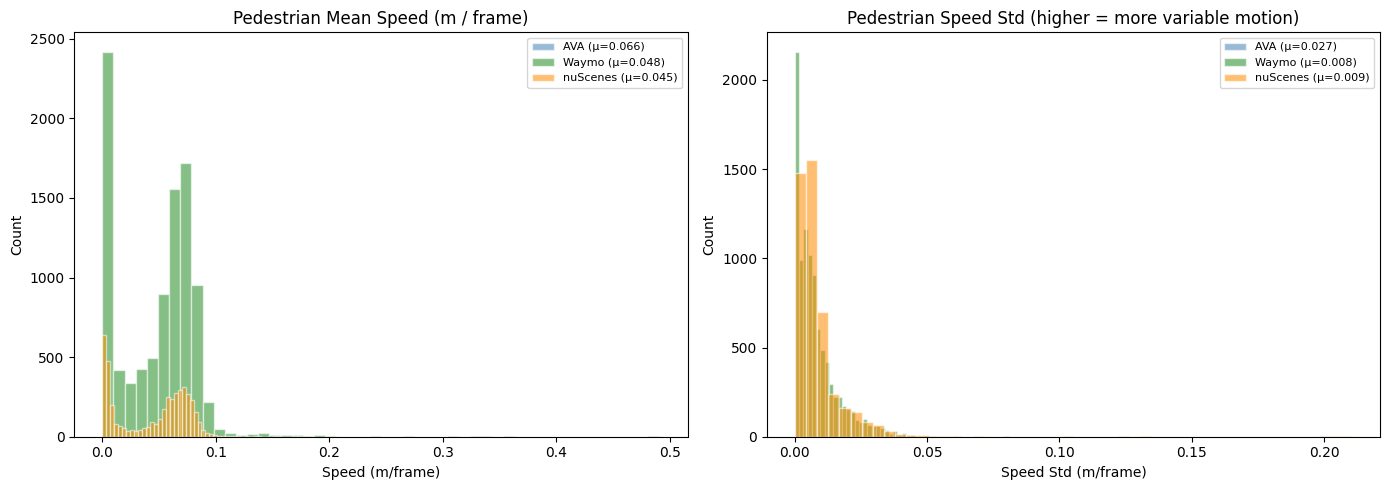

In [13]:
# --- Pedestrian speed distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["ped_mean_speed"]
    ax.hist(subset, bins=50, color=colors[ds], alpha=0.55, edgecolor="white",
            label=f"{ds} (μ={subset.mean():.3f})")
ax.set_title("Pedestrian Mean Speed (m / frame)")
ax.set_xlabel("Speed (m/frame)")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

ax = axes[1]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["ped_speed_std"]
    ax.hist(subset, bins=50, color=colors[ds], alpha=0.55, edgecolor="white",
            label=f"{ds} (μ={subset.mean():.3f})")
ax.set_title("Pedestrian Speed Std (higher = more variable motion)")
ax.set_xlabel("Speed Std (m/frame)")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Scatter: Ped Traveled Distance vs Min Ego–Ped Distance

Scenarios in the **top-left** (high ped travel, low min distance) are the most interactive: the pedestrian moves a lot and the ego gets close.

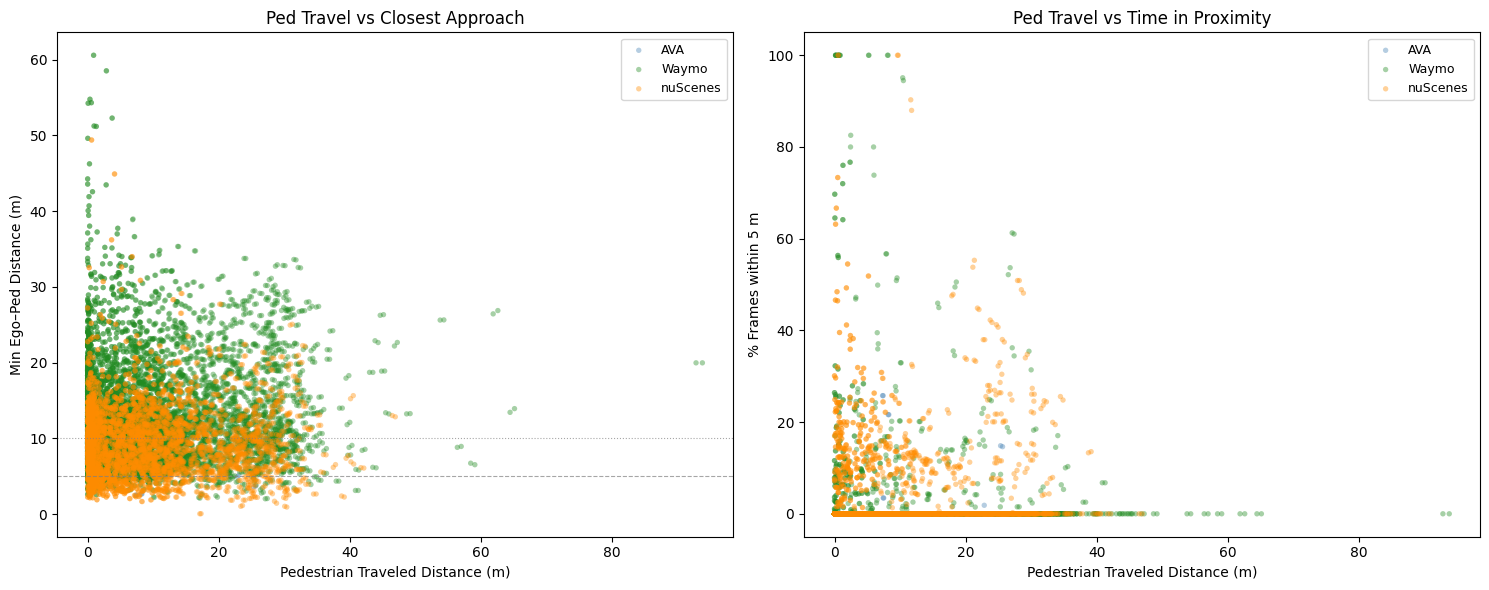

In [14]:
# --- Scatter: ped travel vs min ego-ped distance, colored by dataset ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter 1: ped travel vs min distance
ax = axes[0]
for ds in datasets_in_order:
    s = df[df.dataset == ds]
    ax.scatter(s["ped_travel_dist"], s["min_ego_ped_dist"],
               c=colors[ds], alpha=0.4, s=15, label=ds, edgecolors="none")
ax.set_xlabel("Pedestrian Traveled Distance (m)")
ax.set_ylabel("Min Ego–Ped Distance (m)")
ax.set_title("Ped Travel vs Closest Approach")
ax.axhline(5, color="grey", ls="--", lw=0.8, alpha=0.7)
ax.axhline(10, color="grey", ls=":", lw=0.8, alpha=0.7)
ax.legend(fontsize=9)

# Scatter 2: ped travel vs pct_within_5m
ax = axes[1]
for ds in datasets_in_order:
    s = df[df.dataset == ds]
    ax.scatter(s["ped_travel_dist"], s["pct_within_5m"],
               c=colors[ds], alpha=0.4, s=15, label=ds, edgecolors="none")
ax.set_xlabel("Pedestrian Traveled Distance (m)")
ax.set_ylabel("% Frames within 5 m")
ax.set_title("Ped Travel vs Time in Proximity")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Composite Interaction Score & Top Scenarios

We define a simple **interaction score** that ranks scenarios by how interactive they are. Higher is better:

$$\text{score} = \underbrace{\text{ped\_travel}}_{\text{(ped moves)}} \;\times\; \underbrace{\text{pct\_within\_5m} / 100}_{\text{(close proximity)}} \;\times\; \underbrace{(1 + \text{heading\_change} / 180)}_{\text{(bearing change)}}$$

This favours scenarios where: (1) the pedestrian actually walks, (2) the ego spends time close to the ped, and (3) the relative geometry changes (not just a stationary pass-by).

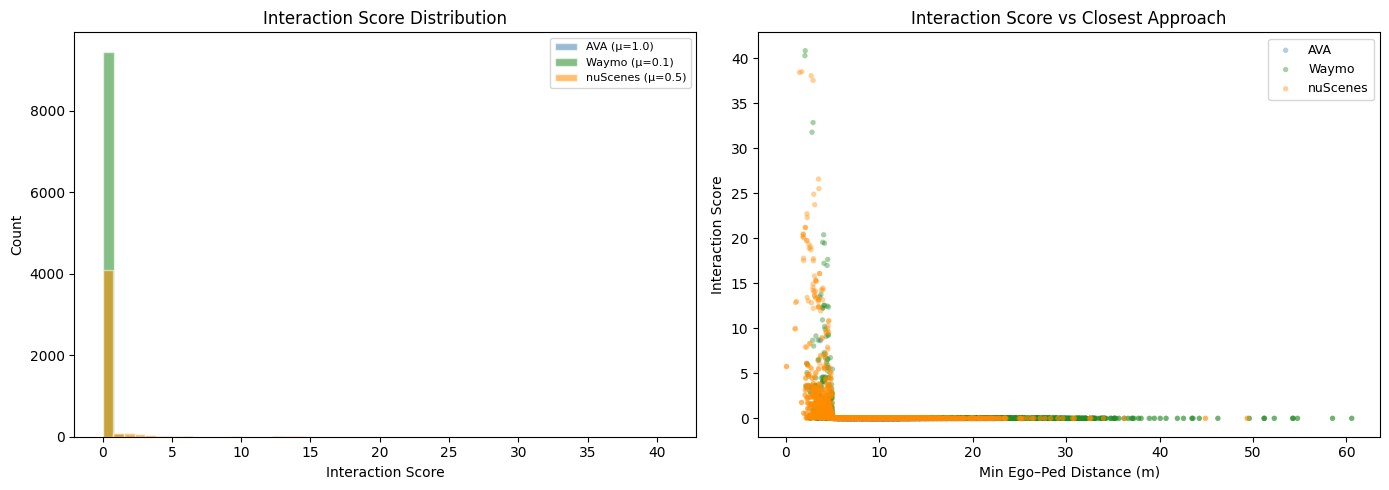

       AVA: score mean=1.0, median=0.0, std=2.3, max=8.7
     Waymo: score mean=0.1, median=0.0, std=1.1, max=40.8
  nuScenes: score mean=0.5, median=0.0, std=2.4, max=38.5


In [15]:
# --- Interaction score ---
df["interaction_score"] = (
    df["ped_travel_dist"]
    * (df["pct_within_5m"] / 100)
    * (1 + df["heading_change_deg"] / 180)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of interaction score
ax = axes[0]
for ds in datasets_in_order:
    subset = df[df.dataset == ds]["interaction_score"]
    ax.hist(subset, bins=50, color=colors[ds], alpha=0.55, edgecolor="white",
            label=f"{ds} (μ={subset.mean():.1f})")
ax.set_title("Interaction Score Distribution")
ax.set_xlabel("Interaction Score")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# Score vs min distance (should show high-score scenarios at low distance)
ax = axes[1]
for ds in datasets_in_order:
    s = df[df.dataset == ds]
    ax.scatter(s["min_ego_ped_dist"], s["interaction_score"],
               c=colors[ds], alpha=0.4, s=15, label=ds, edgecolors="none")
ax.set_xlabel("Min Ego–Ped Distance (m)")
ax.set_ylabel("Interaction Score")
ax.set_title("Interaction Score vs Closest Approach")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Per-dataset score statistics
for ds in datasets_in_order:
    s = df[df.dataset == ds]["interaction_score"]
    print(f"{ds:>10}: score mean={s.mean():.1f}, median={s.median():.1f}, "
          f"std={s.std():.1f}, max={s.max():.1f}")

In [16]:
# --- Top-20 most interactive scenarios ---
show_cols = [
    "dataset", "file", "scene_id", "object_id", "n_frames",
    "ped_travel_dist", "ego_travel_dist",
    "min_ego_ped_dist", "mean_ego_ped_dist",
    "pct_within_5m", "pct_within_10m",
    "approach_ratio", "heading_change_deg",
    "ped_mean_speed", "interaction_score",
]
top = df.nlargest(20, "interaction_score")[show_cols].reset_index(drop=True)
top.index += 1  # 1-based ranking
top.columns = [c.replace("_", " ").title() for c in show_cols]
top.round(2)

,Dataset,File,Scene Id,Object Id,N Frames,Ped Travel Dist,Ego Travel Dist,Min Ego Ped Dist,Mean Ego Ped Dist,Pct Within 5M,Pct Within 10M,Approach Ratio,Heading Change Deg,Ped Mean Speed,Interaction Score
1,Waymo,M552_30.json,552,30,395,27.39,29.21,2.07,4.83,61.01,100.00,0.64,259.54,0.07,40.81
2,Waymo,552_30.json,552,30,395,27.10,29.21,2.03,4.86,61.27,100.00,0.66,256.56,0.07,40.26
3,nuScenes,703_7.json,703,7,401,28.50,61.93,1.71,9.69,48.88,67.83,0.86,317.16,0.07,38.48
4,nuScenes,M703_7.json,703,7,401,28.82,61.93,1.45,9.75,48.13,67.58,0.87,318.35,0.07,38.40
5,nuScenes,M703_8.json,703,8,401,28.19,61.69,2.70,9.75,50.87,67.33,0.84,297.32,0.07,38.03
6,nuScenes,703_8.json,703,8,401,27.91,61.69,2.91,9.73,50.87,67.83,0.84,295.58,0.07,37.52
7,Waymo,M552_12.json,552,12,395,26.79,29.21,2.90,4.94,53.67,100.00,0.47,231.08,0.07,32.84
8,Waymo,552_12.json,552,12,395,26.51,29.21,2.79,4.89,52.15,100.00,0.51,233.50,0.07,31.76
9,nuScenes,M561_11.json,561,11,391,29.40,42.81,3.48,8.42,34.78,68.54,-0.72,287.46,0.08,26.56
10,nuScenes,561_11.json,561,11,391,29.11,42.81,3.52,8.49,34.02,68.03,-0.72,283.66,0.07,25.50


### Correlation Matrix of Interaction Metrics

Helps identify which metrics are redundant vs. complementary for scenario selection.

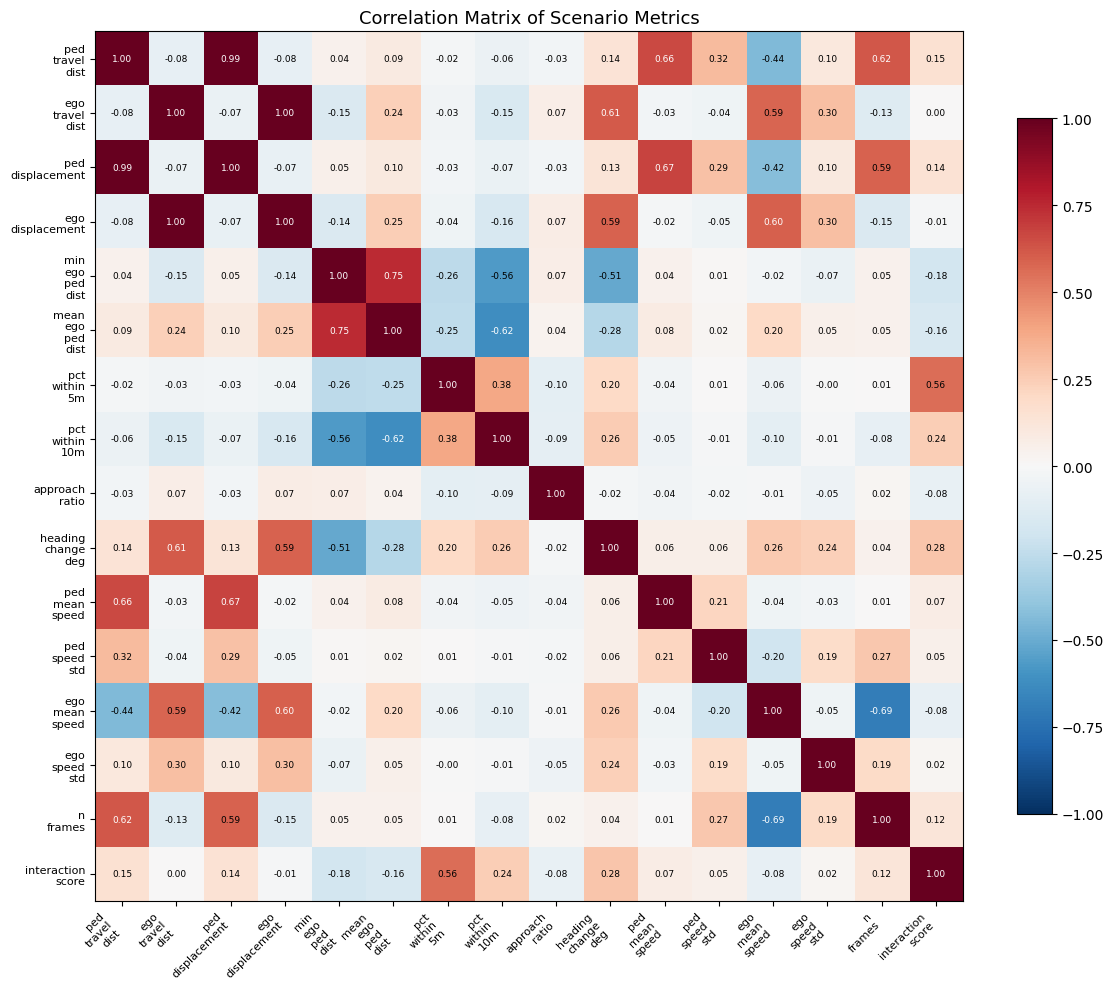

In [17]:
# --- Correlation heatmap ---
corr_cols = [
    "ped_travel_dist", "ego_travel_dist", "ped_displacement", "ego_displacement",
    "min_ego_ped_dist", "mean_ego_ped_dist", "pct_within_5m", "pct_within_10m",
    "approach_ratio", "heading_change_deg",
    "ped_mean_speed", "ped_speed_std", "ego_mean_speed", "ego_speed_std",
    "n_frames", "interaction_score",
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
labels = [c.replace("_", "\n") for c in corr_cols]
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

# Annotate cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6.5, color=color)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Matrix of Scenario Metrics", fontsize=13)
plt.tight_layout()
plt.show()

### Scenario Selection by Interaction Criteria

Apply concrete thresholds to filter scenarios where meaningful interactions occur:
- Pedestrian travels ≥ 1 m (not standing still)
- Ego gets within 10 m at some point
- At least 10% of frames within 5 m proximity

Scenario counts after interaction filtering:
  Before:  14172  total
         AVA:    34 →     6  (18% kept)
       Waymo:  9624 →   150  (2% kept)
    nuScenes:  4514 →   390  (9% kept)
       Total: 14172 →   546  (4% kept)


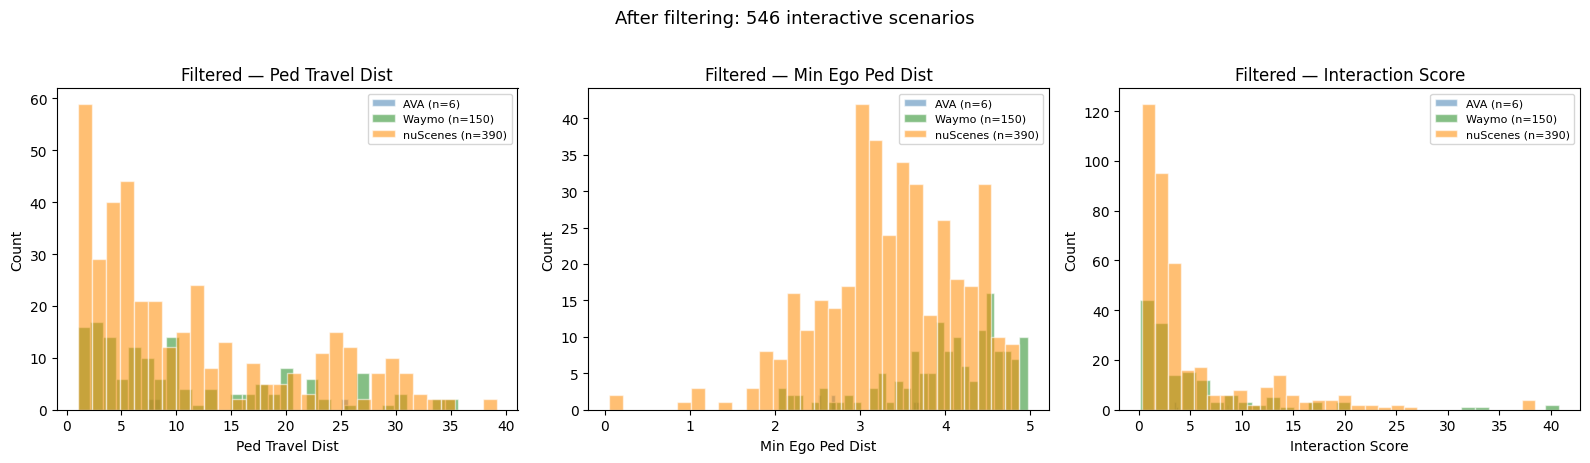

In [18]:
# --- Filter scenarios by interaction criteria ---
THRESHOLDS = {
    "ped_travel_dist": (">=", 1.0),      # ped actually walks
    "min_ego_ped_dist": ("<=", 10.0),     # ego gets within 10 m
    "pct_within_5m": (">=", 10.0),        # at least 10% of time within 5 m
}

mask = pd.Series(True, index=df.index)
for col, (op, val) in THRESHOLDS.items():
    if op == ">=":
        mask &= df[col] >= val
    elif op == "<=":
        mask &= df[col] <= val

df_interactive = df[mask].copy()

print("Scenario counts after interaction filtering:")
print(f"  Before:  {len(df):>5}  total")
for ds in datasets_in_order:
    n_before = (df.dataset == ds).sum()
    n_after = (df_interactive.dataset == ds).sum()
    print(f"  {ds:>10}: {n_before:>5} → {n_after:>5}  ({n_after/n_before*100:.0f}% kept)")
print(f"  {'Total':>10}: {len(df):>5} → {len(df_interactive):>5}  "
      f"({len(df_interactive)/len(df)*100:.0f}% kept)")

# Show distribution of interaction scores for the filtered set
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, metric in enumerate(["ped_travel_dist", "min_ego_ped_dist", "interaction_score"]):
    ax = axes[i]
    for ds in datasets_in_order:
        subset = df_interactive[df_interactive.dataset == ds][metric]
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=30, color=colors[ds], alpha=0.55, edgecolor="white",
                label=f"{ds} (n={len(subset)})")
    nice_name = metric.replace("_", " ").title()
    ax.set_title(f"Filtered — {nice_name}")
    ax.set_xlabel(nice_name)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle(f"After filtering: {len(df_interactive)} interactive scenarios", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# --- Export filtered scenario filenames to train.txt / val.txt ---
out_dir = os.path.dirname(os.path.abspath("dataset_statistics.ipynb"))
ds_prefix = {"AVA": "A", "Waymo": "W", "nuScenes": "N"}

for split in ["train", "val"]:
    subset = df_interactive[df_interactive.split == split]
    names = sorted(ds_prefix[row.dataset] + row.file for _, row in subset.iterrows())
    out_path = os.path.join(out_dir, f"{split}.txt")
    with open(out_path, "w") as f:
        f.write("\n".join(names) + "\n")
    print(f"Wrote {len(names):>5} scenarios → {out_path}")
    for n in names[:3]:
        print(f"    {n}")
    if len(names) > 3:
        print(f"    ...")

Wrote   442 scenarios → /home/erik/ssd2/gitprojects/motion-latent-diffusion/train.txt
    A0001_33.json
    A0015_25.json
    AM0002_26.json
    ...
Wrote   104 scenarios → /home/erik/ssd2/gitprojects/motion-latent-diffusion/val.txt
    A0002_26.json
    AM0001_33.json
    AM0015_25.json
    ...
